In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allel

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
vcf = allel.read_vcf(
    r"C:\Users\PC\OneDrive\Desktop\data\ALL.chr20.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz",
    region="20:1-3000000",
    fields=["samples", "calldata/GT"]
)

print(vcf["calldata/GT"].shape)

(89259, 2504, 2)


In [3]:
!pip install scikit-allel

Defaulting to user installation because normal site-packages is not writeable


In [4]:
gt = vcf["calldata/GT"]

gt_small = gt[:1000, :100]

gn = gt_small[:, :, 0] + gt_small[:, :, 1]

X = gn.T.astype(np.float32)

print(X.shape)

(100, 1000)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

print(X_tensor.shape)

torch.Size([100, 1000])


In [6]:
class GenomicAutoencoder(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        reconstructed = self.decoder(z)

        return reconstructed, z


model = GenomicAutoencoder(
    input_dim=X_tensor.shape[1]
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

GenomicAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1000, bias=True)
  )
)


In [7]:
losses = []

for epoch in range(20):

    optimizer.zero_grad()

    reconstructed, z = model(X_tensor)

    loss = criterion(
        reconstructed,
        X_tensor
    )

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(
        f"Epoch {epoch+1}, Loss: {loss.item():.4f}"
    )

Epoch 1, Loss: 0.1596
Epoch 2, Loss: 0.1577
Epoch 3, Loss: 0.1563
Epoch 4, Loss: 0.1552
Epoch 5, Loss: 0.1542
Epoch 6, Loss: 0.1534
Epoch 7, Loss: 0.1526
Epoch 8, Loss: 0.1518
Epoch 9, Loss: 0.1510
Epoch 10, Loss: 0.1502
Epoch 11, Loss: 0.1493
Epoch 12, Loss: 0.1484
Epoch 13, Loss: 0.1474
Epoch 14, Loss: 0.1463
Epoch 15, Loss: 0.1451
Epoch 16, Loss: 0.1438
Epoch 17, Loss: 0.1423
Epoch 18, Loss: 0.1407
Epoch 19, Loss: 0.1388
Epoch 20, Loss: 0.1368


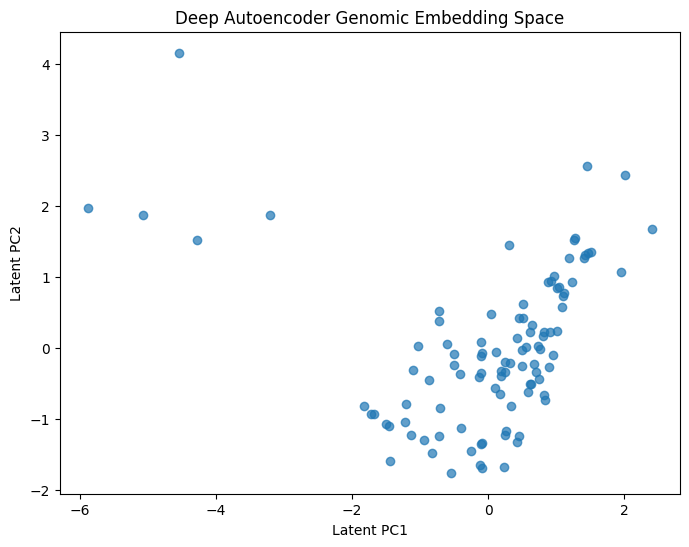

In [8]:
with torch.no_grad():

    _, latent_embeddings = model(X_tensor)

latent_np = latent_embeddings.numpy()

pca = PCA(n_components=2)

latent_pca = pca.fit_transform(latent_np)

plt.figure(figsize=(8,6))

plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    alpha=0.7
)

plt.title("Deep Autoencoder Genomic Embedding Space")

plt.xlabel("Latent PC1")

plt.ylabel("Latent PC2")

plt.savefig(
    r"C:\Users\PC\figures\deep_autoencoder_genomic_embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

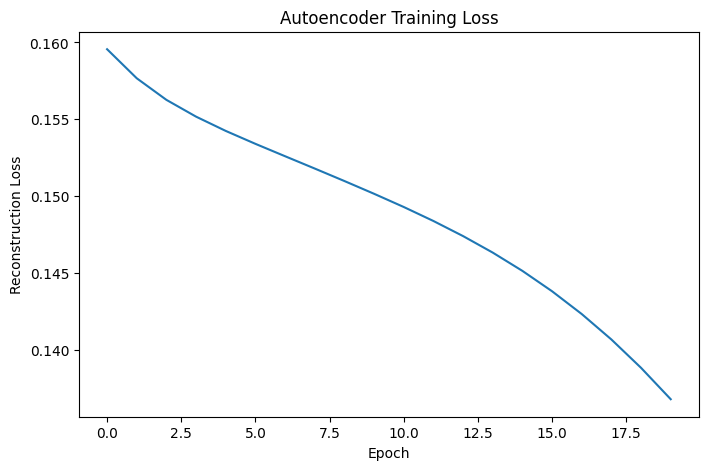

In [9]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Autoencoder Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Reconstruction Loss")

plt.savefig(
    r"C:\Users\PC\figures\autoencoder_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()